# XGBoost Regressor Model for Typhoon-Related Prediction

This notebook implements an end-to-end **XGBoost Regressor pipeline** designed to predict the **casualties caused by typhoons**.

The workflow includes:
- Data loading and exploration
- Feature selection and preprocessing
- Train-test splitting
- XGBoost Regressor model training
- Hyperparameter tuning
- Model evaluation using regression metrics
- Scenario-based prediction testing
- Exporting prediction results

## 1. Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Optimization and Saving
import optuna
import joblib
import warnings
import os

# Settings
sns.set(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("Libraries imported.")

Libraries imported.


c:\Users\Charles\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load And Explore Dataset

In [2]:
TARGET_COLUMN = 'dead' 
INPUT_FILE = '../../../../data/typhoon_impact_with_extreme_weather.csv'

try:
    print(f"LOADING DATASET...")
    df = pd.read_csv(INPUT_FILE)
    
    # Standardize Column Names (Lowercase, underscores)
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('/', '_')
    
    # Rename columns to standard format
    rename_map = {
        'typhoon': 'typhoon_name',
        'wind_speed': 'max_sustained_wind_kph',
        'rainfall': 'max_24hr_rainfall_mm',
        'pressure': 'min_pressure_hpa',
        'storm_rainfall': 'total_storm_rainfall_mm',
        'duration': 'duration_in_par_hours'
    }
    df.rename(columns=rename_map, inplace=True)
    
    print(f"Data Loaded Successfully.")
    print(f"Total Rows: {len(df)}") 
    print(f"Columns: {list(df.columns)}")

except FileNotFoundError:
    print(f"Error: '{INPUT_FILE}' not found.")

LOADING DATASET...
Data Loaded Successfully.
Total Rows: 1776
Columns: ['typhoon_name', 'year', 'region', 'province', 'city_municipality', 'families', 'person', 'brgy', 'dead', 'injured_ill', 'missing', 'totally', 'partially', 'total', 'quantity', 'cost', 'nearest_station', 'station_province', 'distance_km', 'par_start', 'par_end', 'duration_in_par_hours', 'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa', 'weather_station_mapped', 'weather_records_found', 'weather_days_covered']


In [3]:
df.head()

,typhoon_name,year,region,province,city_municipality,families,person,brgy,dead,injured_ill,...,par_end,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_station_mapped,weather_records_found,weather_days_covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   typhoon_name             1776 non-null   object 
 1   year                     1776 non-null   int64  
 2   region                   1776 non-null   int64  
 3   province                 1776 non-null   object 
 4   city_municipality        1776 non-null   object 
 5   families                 1776 non-null   int64  
 6   person                   1776 non-null   int64  
 7   brgy                     1776 non-null   int64  
 8   dead                     1776 non-null   int64  
 9   injured_ill              1776 non-null   int64  
 10  missing                  1776 non-null   int64  
 11  totally                  1776 non-null   int64  
 12  partially                1776 non-null   int64  
 13  total                    1776 non-null   int64  
 14  quantity                

In [5]:
df.describe()

,year,region,families,person,brgy,dead,injured_ill,missing,totally,partially,...,cost,distance_km,duration_in_par_hours,max_sustained_wind_kph,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_station_mapped,weather_records_found,weather_days_covered
count,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,...,1.776000e+03,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.0,1776.000000,1776.000000
mean,2021.216779,4.628941,1319.164414,5085.457770,8.808559,0.118243,0.329392,0.005631,56.121059,204.176802,...,3.067556e+05,37.478268,117.337669,139.304617,103.854302,168.839127,995.812331,1.0,5.604167,5.604167
std,0.943932,2.072282,3645.909584,13943.350619,11.442813,2.617296,2.711094,0.111187,399.704541,1029.153384,...,1.276232e+06,21.034558,37.039775,50.960721,71.202587,111.019046,10.057188,0.0,1.279685,1.279685
min,2020.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.131955,39.000000,45.000000,0.000000,0.000000,924.900000,1.0,2.000000,2.000000
25%,2020.000000,3.000000,16.000000,57.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,20.455268,91.000000,110.000000,50.400000,78.902500,992.200000,1.0,5.000000,5.000000
50%,2021.000000,5.000000,152.500000,589.500000,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,34.709542,122.000000,120.000000,98.500000,151.200000,998.100000,1.0,6.000000,6.000000
75%,2022.000000,5.000000,969.750000,3639.250000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,53.319704,124.700000,195.000000,136.200000,237.200000,1001.800000,1.0,6.000000,6.000000
max,2023.000000,8.000000,60550.000000,195016.000000,122.000000,95.000000,56.000000,4.000000,6588.000000,16719.000000,...,1.620751e+07,103.723427,198.000000,225.000000,510.000000,770.500000,1008.600000,1.0,8.000000,8.000000


## 3. Data Preprocessing

In [6]:
REMOVE_EXTREME_OUTLIERS = False 

try:
    print(f"ANALYSIS TARGET: {TARGET_COLUMN.upper()}")
    df = pd.read_csv(INPUT_FILE)
    
    # 1. Standardize Column Names
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('/', '_')
    
    # 2. Rename columns (Matching your dataset standards)
    rename_map = {
        'typhoon': 'typhoon_name',
        'wind_speed': 'max_sustained_wind_kph',
        'rainfall': 'max_24hr_rainfall_mm',
        'pressure': 'min_pressure_hpa',
        'storm_rainfall': 'total_storm_rainfall_mm',
        'duration': 'duration_in_par_hours'
    }
    df.rename(columns=rename_map, inplace=True)

    # 3. Clean Target Column
    if TARGET_COLUMN in df.columns:
        if df[TARGET_COLUMN].dtype == 'object':
            df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.replace(',', '')
        df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').fillna(0)
    else:
        raise ValueError(f"Target '{TARGET_COLUMN}' not found.")

    # 4. BASIC FILTER: Remove 0s (Non-events)
    # We only train on rows where the event actually occurred.
    df_clean = df[df[TARGET_COLUMN] > 0].copy()
    
    # =========================================================
    # 5. SCENARIO LOGIC (THE TOGGLE)
    # =========================================================
    if REMOVE_EXTREME_OUTLIERS:
        # Scenario B: Remove the most extreme values
        max_val = df_clean[TARGET_COLUMN].max()
        print(f"SCENARIO: REMOVING EXTREME OUTLIERS (Values >= {max_val})")
        df_clean = df_clean[df_clean[TARGET_COLUMN] < max_val]
    else:
        # Scenario A: Keep everything
        print(f"SCENARIO: KEEPING ALL OUTLIERS (Training on full range).")
    # =========================================================

    # 6. Handle Missing Weather Data
    weather_cols = ['max_sustained_wind_kph', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa']
    for col in weather_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    print(f"\nData Ready.")
    print(f"Original Rows: {len(df)}")
    print(f"Training Rows: {len(df_clean)}")
    print(f"Max Value in Training Data: {df_clean[TARGET_COLUMN].max()}")

except FileNotFoundError:
    print(f"Error: '{INPUT_FILE}' not found.")

ANALYSIS TARGET: DEAD
SCENARIO: KEEPING ALL OUTLIERS (Training on full range).

Data Ready.
Original Rows: 1776
Training Rows: 41
Max Value in Training Data: 95


## 4. Train-Test Split

In [7]:
input_features = [
    'max_sustained_wind_kph',
    'max_24hr_rainfall_mm',
    'total_storm_rainfall_mm',
    'min_pressure_hpa',
    'duration_in_par_hours'
]

# Select X and y
X = df_clean[input_features]
y = df_clean[TARGET_COLUMN]

# Split Data (80% Train, 20% Test)
# Note: We keep the index to retrieve metadata later
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Complete.")
print(f"Training Samples: {X_train_raw.shape[0]}")
print(f"Testing Samples:  {X_test_raw.shape[0]}")

Data Split Complete.
Training Samples: 32
Testing Samples:  9


## 5. Scaling

In [8]:
# Initialize Scaler
scaler = StandardScaler()

# Fit on Train, Transform both Train and Test
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Features Scaled.")
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape:  {X_test.shape}")

Features Scaled.
Train Shape: (32, 5)
Test Shape:  (9, 5)


## 6. XGBoost Regressor Model Training

In [9]:
# Initialize and Train Default XGBoost
baseline_model = xgb.XGBRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

# Predict on Test Set
y_pred_base = np.maximum(baseline_model.predict(X_test), 0)

# Evaluate Baseline
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"BASELINE XGBOOST RESULTS:")
print(f"R2 Score: {base_r2:.4f}")
print(f"RMSE:     {base_rmse:,.2f}")

BASELINE XGBOOST RESULTS:
R2 Score: 0.9783
RMSE:     2.47


## 7. Hyperparameter Tuning Using Optuna

In [10]:
def objective(trial):
    # Suggest XGBoost Hyperparameters
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'n_jobs': -1,
        'random_state': 42
    }
    
    model = xgb.XGBRegressor(**param)
    
    # Cross Validation
    cv_folds = 3 if len(X_train) > 10 else 2
    
    # Minimize Negative MSE
    score = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
    return np.sqrt(-score.mean()) # Return RMSE

# Run Optimization
print("Starting Optuna Tuning for XGBoost...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Tuning Complete.")
print(f"Best Validation RMSE: {study.best_value:.4f}")
print("Best Params:", study.best_params)

Starting Optuna Tuning for XGBoost...
Tuning Complete.
Best Validation RMSE: 16.9734
Best Params: {'n_estimators': 111, 'max_depth': 4, 'learning_rate': 0.01034039620453367, 'subsample': 0.8428735314694175, 'colsample_bytree': 0.8962866210087659, 'reg_alpha': 1.6152765899383297, 'reg_lambda': 6.871369386166806}


In [11]:
# Initialize XGBoost with Best Parameters
final_model = xgb.XGBRegressor(**study.best_params, random_state=42)

# Train on full training data
final_model.fit(X_train, y_train)

print("Final Tuned XGBoost Model Trained.")

Final Tuned XGBoost Model Trained.


## 8. Model Validation And Evaluation

In [12]:
# --- COMPARISON: BASELINE vs TUNED MODEL ---
# 1. Get Predictions
y_pred_base = np.maximum(baseline_model.predict(X_test), 0)
y_pred_tuned = np.maximum(final_model.predict(X_test), 0)

# 2. Calculate Metrics for Baseline
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base) )
base_mae = mean_absolute_error(y_test, y_pred_base)

# 3. Calculate Metrics for Tuned Model
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

# 4. Create Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Baseline Model': [base_r2, base_rmse, base_mae],
    'Optuna Tuned Model': [tuned_r2, tuned_rmse, tuned_mae],
    'Improvement': [
        tuned_r2 - base_r2,
        base_rmse - tuned_rmse,
        base_mae - tuned_mae
    ]
})

print(f"MODEL COMPARISON REPORT ({TARGET_COLUMN.upper()})")
print("=" * 60)
print(comparison_df.to_string(index=False, float_format="%.4f"))
print("=" * 60)

if tuned_rmse < base_rmse:
    print(f"SUCCESS: Optuna tuning improved RMSE by {base_rmse - tuned_rmse:,.2f}")
else:
    print(f"NOTE: Tuning did not significantly improve performance.")

MODEL COMPARISON REPORT (DEAD)
  Metric  Baseline Model  Optuna Tuned Model  Improvement
R² Score          0.9783              0.3458      -0.6325
    RMSE          2.4681             13.5502     -11.0821
     MAE          1.3045              5.6814      -4.3769
NOTE: Tuning did not significantly improve performance.


## 9. Model Output and Summary

In [13]:
# --- 1. SELECTION LOGIC (Auto-select Best Model) ---
if base_rmse < tuned_rmse:
    print("SELECTION UPDATE: Baseline Model performed better.")
    print("Swapping 'final_model' to use the Baseline (Default) configuration.")
    final_model = baseline_model
else:
    print("SELECTION UPDATE: Optuna Tuned Model performed better.")
    print("Keeping the Tuned configuration.")
print("-" * 60)


# --- 2. GENERATE PREDICTIONS ---
y_pred_final = np.maximum(final_model.predict(X_test), 0)


# --- 3. CALCULATE METRICS ---
r2 = r2_score(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae = mean_absolute_error(y_test, y_pred_final)



# --- 5. PRINT FINAL METRICS ---
print(f"FINAL MODEL PERFORMANCE ({TARGET_COLUMN.upper()})")
print("=" * 40)
print(f"R² Score:  {r2:.4f}")
print(f"RMSE:      {rmse:,.4f}")
print(f"MAE:       {mae:,.4f}")
print("=" * 40)


SELECTION UPDATE: Baseline Model performed better.
Swapping 'final_model' to use the Baseline (Default) configuration.
------------------------------------------------------------
FINAL MODEL PERFORMANCE (DEAD)
R² Score:  0.9783
RMSE:      2.4681
MAE:       1.3045


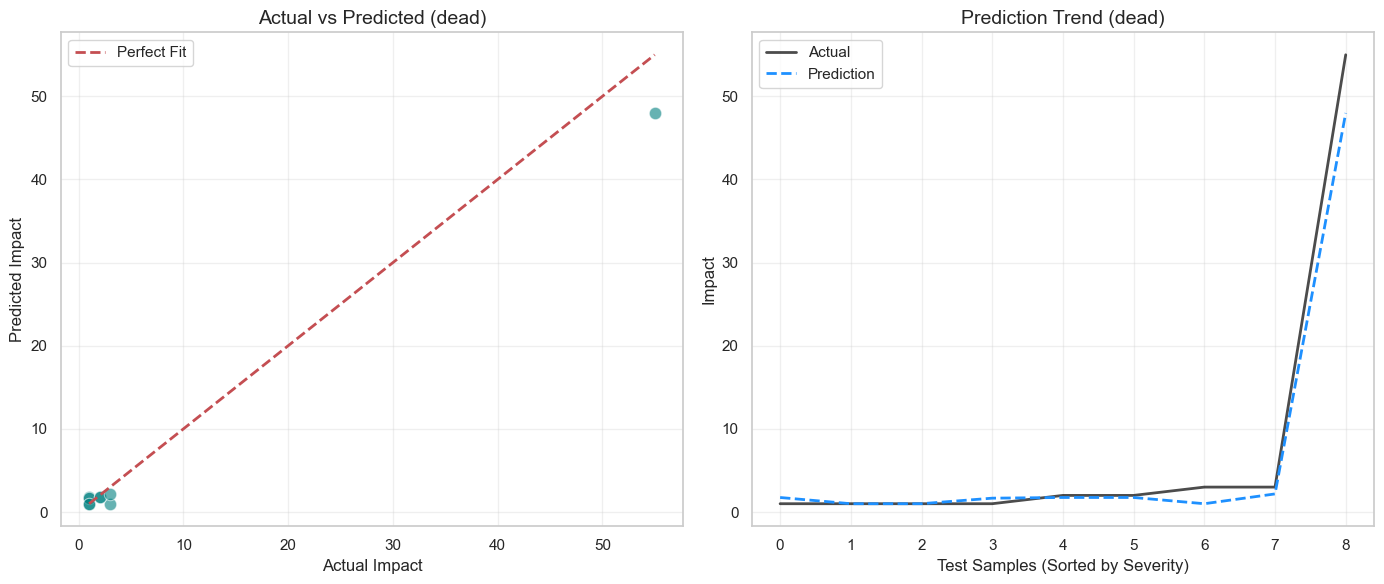

In [14]:
# --- 4. VISUALIZATION: Actual vs Predicted ---
plt.figure(figsize=(14, 6))

# Plot A: Scatter Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6, s=80, color='teal')
# Perfect fit line
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

plt.title(f'Actual vs Predicted ({TARGET_COLUMN})', fontsize=14)
plt.xlabel('Actual Impact')
plt.ylabel('Predicted Impact')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot B: Trend Line (Sorted)
plt.subplot(1, 2, 2)
sorted_idx = np.argsort(y_test.values)
plt.plot(y_test.values[sorted_idx], label='Actual', color='black', linewidth=2, alpha=0.7)
plt.plot(y_pred_final[sorted_idx], label='Prediction', color='dodgerblue', linestyle='--', linewidth=2)

plt.title(f'Prediction Trend ({TARGET_COLUMN})', fontsize=14)
plt.xlabel('Test Samples (Sorted by Severity)')
plt.ylabel('Impact')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# --- 6. PREPARE OUTPUT DATAFRAME ---
# Define metadata and key features to include for context
meta_cols = ['typhoon_name', 'province', 'city_municipality', 'year']

# Check which ones are actually in your dataframe to avoid errors
available_meta = [c for c in meta_cols if c in df_clean.columns]

# Retrieve metadata for the specific rows in the test set using the index
test_metadata = df_clean.loc[y_test.index, available_meta].copy()

# Create the prediction results dataframe
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': np.round(np.maximum(final_model.predict(X_test), 0)).astype(int)
}, index=y_test.index)

# Concatenate the metadata with the results
final_output = pd.concat([test_metadata, results_df], axis=1)

# Sort by Typhoon Name (A-Z) then Year (Ascending) for easier reading
if 'typhoon_name' in final_output.columns and 'year' in final_output.columns:
    final_output.sort_values(by=['typhoon_name', 'year'], ascending=[True, True], inplace=True)

# Display a sample of the output
print("\nPrediction Sample (First 5 Test Rows):")
display(final_output.head())


Prediction Sample (First 5 Test Rows):


,typhoon_name,province,city_municipality,year,Actual,Predicted
1517,AGATON,LEYTE,ABUYOG,2022,55,48
1546,DANTE,LEYTE,CALUBIAN,2021,3,2
1482,ODETTE,EASTERN SAMAR,LAWAAN,2021,1,2
1756,ODETTE,SOUTHERN LEYTE,TOMAS OPPUS,2021,2,2
1755,ODETTE,SOUTHERN LEYTE,SOGOD,2021,2,2


## 10. Saving The Model

In [16]:
# --- 1. Save Predictions to CSV ---
csv_filename = f'results_xgb_{TARGET_COLUMN}.csv'
final_output.to_csv(csv_filename, index=False)
print(f"Prediction results saved to: {csv_filename}")

Prediction results saved to: results_xgb_dead.csv


## 11. Manual Validation (For Testing)

In [17]:
# --- MANUAL VALIDATION FUNCTION ---
def test_prediction(wind_kph, rain_24hr, storm_rain_mm, pressure_hpa, duration_hours):
    """
    Tests the XGBoost model with custom values.
    """
    # 1. Create Input
    input_data = pd.DataFrame({
        'max_sustained_wind_kph': [wind_kph],
        'max_24hr_rainfall_mm': [rain_24hr],
        'total_storm_rainfall_mm': [storm_rain_mm],
        'min_pressure_hpa': [pressure_hpa],
        'duration_in_par_hours': [duration_hours]
    })

    # 2. Scale
    input_scaled = scaler.transform(input_data)

    # 3. Predict
    prediction = final_model.predict(input_scaled)
    final_value = int(np.round(max(prediction[0], 0)))

    print(f"TEST INPUTS:")
    print(f"Wind: {wind_kph} kph | Rain (24h): {rain_24hr} mm | Pressure: {pressure_hpa} hPa")
    print(f"-----------------------------------------------------------")
    print(f"PREDICTED {TARGET_COLUMN.upper()}: {final_value:,.2f}")
    print(f"-----------------------------------------------------------\n")

In [18]:
print("Average Typhoon")
test_prediction(wind_kph=150, rain_24hr=100, storm_rain_mm=150, pressure_hpa=980, duration_hours=48)
print("Strong Typhoon")
test_prediction(wind_kph=180, rain_24hr=250, storm_rain_mm=300, pressure_hpa=960, duration_hours=48)
print("Super Typhoon (Wind Dominant)")
test_prediction(wind_kph=240, rain_24hr=200, storm_rain_mm=300, pressure_hpa=920, duration_hours=48)
print("Rain-Induced (Slow Moving)")
test_prediction(wind_kph=100, rain_24hr=500, storm_rain_mm=800, pressure_hpa=985, duration_hours=72)
print("Extreme Catastrophe (Yolanda Level)")
test_prediction(wind_kph=315, rain_24hr=400, storm_rain_mm=500, pressure_hpa=895, duration_hours=48)

Average Typhoon
TEST INPUTS:
Wind: 150 kph | Rain (24h): 100 mm | Pressure: 980 hPa
-----------------------------------------------------------
PREDICTED DEAD: 1.00
-----------------------------------------------------------

Strong Typhoon
TEST INPUTS:
Wind: 180 kph | Rain (24h): 250 mm | Pressure: 960 hPa
-----------------------------------------------------------
PREDICTED DEAD: 1.00
-----------------------------------------------------------

Super Typhoon (Wind Dominant)
TEST INPUTS:
Wind: 240 kph | Rain (24h): 200 mm | Pressure: 920 hPa
-----------------------------------------------------------
PREDICTED DEAD: 1.00
-----------------------------------------------------------

Rain-Induced (Slow Moving)
TEST INPUTS:
Wind: 100 kph | Rain (24h): 500 mm | Pressure: 985 hPa
-----------------------------------------------------------
PREDICTED DEAD: 1.00
-----------------------------------------------------------

Extreme Catastrophe (Yolanda Level)
TEST INPUTS:
Wind: 315 kph | Rain (2

In [19]:
test_prediction(wind_kph=100, rain_24hr=80, storm_rain_mm=150, pressure_hpa=980, duration_hours=48)

TEST INPUTS:
Wind: 100 kph | Rain (24h): 80 mm | Pressure: 980 hPa
-----------------------------------------------------------
PREDICTED DEAD: 1.00
-----------------------------------------------------------



## JOBLIB

In [20]:
TARGET = 'dead'
OUTPUT_DIR = os.path.join('models', 'prediction') 

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..', '..'))
OUTPUT_DIR = os.path.join(project_root, 'models', 'prediction')

# --- SAVE ARTIFACTS ---
print(f"Saving Linear Regression Artifacts for {TARGET} to '{OUTPUT_DIR}'...")

# 2. Define Paths
model_path = os.path.join(OUTPUT_DIR, f'{TARGET}_model.joblib')
scaler_path = os.path.join(OUTPUT_DIR, f'{TARGET}_scaler.joblib')
features_path = os.path.join(OUTPUT_DIR, f'{TARGET}_features.joblib')

# 3. Save Files
joblib.dump(final_model, model_path)
joblib.dump(scaler, scaler_path)

# Save Feature Columns 
if hasattr(X_train, 'columns'):
    feature_cols = list(X_train.columns)
else:
    feature_cols = ['max_sustained_wind_kph', 'max_24hr_rainfall_mm', 
                    'total_storm_rainfall_mm', 'min_pressure_hpa', 'duration_in_par_hours']
joblib.dump(feature_cols, features_path)

print(f"Successfully saved files to: {OUTPUT_DIR}")

Saving Linear Regression Artifacts for dead to 'c:\Users\Charles\Documents\GitHub\Clustering-for-Post-Tropical-Cyclone-Impact-Profiling-in-the-Philippines\models\prediction'...
Successfully saved files to: c:\Users\Charles\Documents\GitHub\Clustering-for-Post-Tropical-Cyclone-Impact-Profiling-in-the-Philippines\models\prediction
